#### 6.3 绘制动态图表分析产品走势

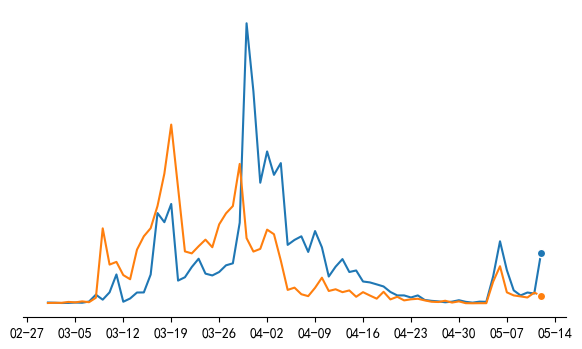

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.dates as mdates # 导入日期模块
import pandas as pd

# 1. 数据准备
# 读取Excel文件
df=pd.read_excel("data6.xlsx")
# 解决中文乱码
plt.rcParams['font.sans-serif']=['SimHei']

# 2. 设置画布
fig = plt.figure(figsize=(7, 4))
# 设置x轴数据
x = df['日期']
# 设置第一个y轴和第二个y轴数据
y1, y2 =df['产品1'], df['产品2']

# 3.绘制动态图表
# 创建子图返回坐标轴对象axes
ax = plt.subplot()
# 第一个y轴折线图
(line1,) = ax.plot(x, y1,   # xy轴数据
                   marker="o", # 标记
                   markevery=[-1], # 设置每个点只显示一个标记
                   markeredgecolor="white")  # 标记边的颜色
# 第二个y轴折线图
(line2,) = ax.plot(x, y2, marker="o",markevery=[-1], markeredgecolor="white")
# 设置注释文本（在日期所在的位置显示数据）
text1 = ax.text(x[0],y1[0], '', ha="left", va="top")
text2 = ax.text(x[0],y2[0], '', ha="left", va="top")
# 设置x坐标轴刻度为x
ax.set_xticks(x)
# 设置y坐标轴刻度为空
ax.set_yticks([])
# 设置连接坐标轴刻度的线不可见
# spines是连接坐标轴刻度的线
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
# 日期显示格式为月日
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# 日期刻度定位为星期
ax.xaxis.set_major_locator(mdates.WeekdayLocator())

# 自定义更新函数update
def update(frame):
    line1.set_data(x[:frame+1], y1[:frame+1])
    line2.set_data(x[:frame+1], y2[:frame+1])
    text1.set_position((x[frame], y1[frame]))
    text1.set_text(f'产品1: {y1[frame]}')
    text2.set_position((x[frame], y2[frame]))
    text2.set_text(f'产品2: {y2[frame]}')
    return line1,line2

# 执行动画
ani = animation.FuncAnimation(fig, update, interval=100,frames=len(x))
# 显示图表
plt.show()
# 将动画保存为.gif格式
ani.save('myline.gif',writer='pillow',fps=100)